In [1]:
from preprocessing import get_patch_list, get_labels, get_combined_generator, MultimodalDataGenerator
from models import build_model
from gradcam import make_gradcam_heatmap, overlay_heatmap

from config import *

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

import os
import random
import warnings

from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

# Parameters

In [3]:
NUM_CLASSES = 1
IMAGE_SIZE = 128

# DATA
BATCH_SIZE = 8

# OPTIMIZER
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

# TRAINING
EPOCHS = 50

In [4]:
train_patches_dir = "../../donnees_terrain/donnees_modifiees/train_test_split/train_test_split_100m/train_patches/"
val_patches_dir = "../../donnees_terrain/donnees_modifiees/train_test_split/train_test_split_100m/val_patches/"
test_patches_dir = "../../donnees_terrain/donnees_modifiees/train_test_split/train_test_split_100m/test_patches/"

sites = ["fao", "timbertiere", "cisse", "louroux"]
variables = ["Drone_MS_patches"]
distance = [100]

order = "plecoptera"

# Import and split data paths

In [5]:
train_patches = np.stack([get_patch_list(train_patches_dir, i, sites=sites, distances=distance) for i in variables], axis=-1)
test_patches = np.stack([get_patch_list(test_patches_dir, i, sites=sites, distances=distance) for i in variables], axis=-1)
val_patches = np.stack([get_patch_list(val_patches_dir, i, sites=sites, distances=distance) for i in variables], axis=-1)

train_image_patches = get_patch_list(train_patches_dir, variables[0], sites=sites)
test_image_patches = get_patch_list(test_patches_dir, variables[0], sites=sites)
val_image_patches = get_patch_list(val_patches_dir, variables[0], sites=sites)

In [6]:
train_patches.shape, test_patches.shape, val_patches.shape

((124, 1), (41, 1), (31, 1))

In [7]:
df_labels = pd.read_csv('../labels_rsec2026.csv', index_col="Unnamed: 0")

In [8]:
train_labels = get_labels(df_labels, train_image_patches, order)
test_labels = get_labels(df_labels, test_image_patches, order)
val_labels = get_labels(df_labels, val_image_patches, order)

In [9]:
train_selected_indices = random.sample(range(len(train_labels)), len(train_labels))
test_selected_indices = random.sample(range(len(test_labels)), len(test_labels))
val_selected_indices = random.sample(range(len(val_labels)), len(val_labels))

In [10]:
train_patches = [train_patches[i] for i in train_selected_indices]
train_labels = [train_labels[i] for i in train_selected_indices]

val_patches = [val_patches[i] for i in val_selected_indices]
val_labels = [val_labels[i] for i in val_selected_indices]

test_patches = [test_patches[i] for i in test_selected_indices]
test_labels = [test_labels[i] for i in test_selected_indices]

In [11]:
labels = train_labels + val_labels + test_labels
print(f"proportion of Ephemeropteres in whole dataset: {round(np.sum(np.array(labels) > 0)/len(labels), 3)}%")
print(f"proportion of Ephemeropteres in train dataset: {round(np.sum(np.array(train_labels) > 0)/len(train_labels), 3)}%")
print(f"proportion of Ephemeropteres in val dataset: {round(np.sum(np.array(val_labels) > 0)/len(val_labels), 3)}%")
print(f"proportion of Ephemeropteres in test dataset: {round(np.sum(np.array(test_labels) > 0)/len(test_labels), 3)}%")

proportion of Ephemeropteres in whole dataset: 0.423%
proportion of Ephemeropteres in train dataset: 0.452%
proportion of Ephemeropteres in val dataset: 0.387%
proportion of Ephemeropteres in test dataset: 0.366%


# Load and preprocess data

In [12]:
train_gen = get_combined_generator(
    img_paths=train_patches, batch_size=8, labels=train_labels, mixup_second_gen=True, ms_size=40, single_modality=True
)
test_gen = MultimodalDataGenerator(
    img_paths=test_patches, batch_size=8, labels=test_labels, shuffle=False, ms_size=40, single_modality=True
)
val_gen = MultimodalDataGenerator(
    img_paths=val_patches, batch_size=8, labels=val_labels, shuffle=False, ms_size=40, single_modality=True
)

In [13]:
batch = test_gen.__getitem__(3)

In [29]:
batch[0].shape

(8, 40, 40, 5)

In [30]:
batch[1]

array([0., 0., 0., 1., 1., 0., 0., 0.])

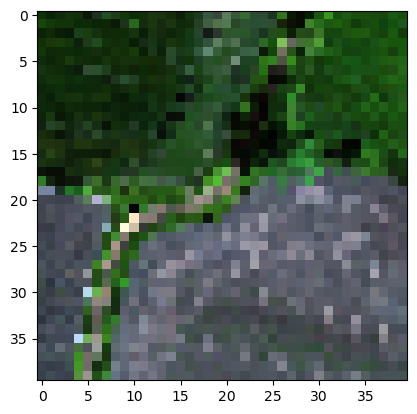

In [16]:
plt.imshow(batch[0][1, :,:,:3])

# Define and compile model

In [17]:
# Example usage
model = build_model(ms_shape=(40, 40, 5), num_classes=1)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ tinycerberuscnn_input         │ (None, 40, 40, 5)         │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 40, 40, 64)        │             384 │ tinycerberuscnn_input[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 40, 40, 64)        │           2,944 │ tinycerberuscnn_input[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_2    │ (None, 5)                 │               0 │ tinycerberuscnn_input[0][… │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 40, 40, 64)        │             256 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 40, 40, 64)        │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │             384 │ global_average_pooling2d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 64)                │               0 │ batch_normalization[0][0]  │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 64)                │               0 │ batch_normalization_1[0][… │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 64)                │             256 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 192)               │               0 │ global_average_pooling2d[… │
│                               │                           │                 │ global_average_pooling2d_… │
│                               │                           │                 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 128)               │          24,704 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               

 Total params: 29,313 (114.50 KB)

 Trainable params: 28,929 (113.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
optimizer = AdamW(
    learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name='auc')
    ],
)

# Train model

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=max([5, EPOCHS//10]), restore_best_weights=True),
            ]

tracker = EmissionsTracker(experiment_id='CO2_tracking', 
                           measure_power_secs=180, 
                           allow_multiple_runs=True)
tracker.start()
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


[codecarbon WARNING @ 18:24:06] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:24:06] [setup] RAM Tracking...
[codecarbon INFO @ 18:24:06] [setup] CPU Tracking...
[codecarbon WARNING @ 18:24:08] We saw that you have a Intel(R) Core(TM) Ultra 5 135H but we don't know it. Please contact us.
[codecarbon WARNING @ 18:24:08] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 18:24:08] CPU Model on constant consumption mode: Intel(R) Core(TM) Ultra 5 135H
[codecarbon WARNING @ 18:24:08] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:24:08] [setup] GPU Tracking...
[codecarbon INFO @ 18:24:10] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:24:10] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: 

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5323 - auc: 0.6897 - loss: 0.6567 - val_accuracy: 0.5806 - val_auc: 0.8618 - val_loss: 0.6835
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 991ms/step - accuracy: 0.5685 - auc: 0.7767 - loss: 0.5916 - val_accuracy: 0.4516 - val_auc: 0.8224 - val_loss: 0.6927
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5968 - auc: 0.8329 - loss: 0.5172 - val_accuracy: 0.4839 - val_auc: 0.7368 - val_loss: 0.6757
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6129 - auc: 0.8007 - loss: 0.5245 - val_accuracy: 0.5806 - val_auc: 0.8969 - val_loss: 0.6646
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6169 - auc: 0.8353 - loss: 0.4910 - val_accuracy: 0.4516 - val_auc: 0.9057 - val_loss: 0.6739
Epoch 6/50


[codecarbon INFO @ 18:27:10] Energy consumed for RAM : 0.001000 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:27:10] Delta energy consumed for CPU with constant : 0.002125 kWh, power : 42.5 W
[codecarbon INFO @ 18:27:10] Energy consumed for All CPU : 0.002125 kWh
[codecarbon INFO @ 18:27:11] Energy consumed for all GPUs : 0.000014 kWh. Total GPU Power : 0.2898484110621772 W
[codecarbon INFO @ 18:27:11] 0.003140 kWh of electricity and 0.000000 L of water were used since the beginning.


31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 992ms/step - accuracy: 0.5766 - auc: 0.8219 - loss: 0.5072 - val_accuracy: 0.5161 - val_auc: 0.8706 - val_loss: 0.6713
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6331 - auc: 0.8389 - loss: 0.4711 - val_accuracy: 0.6452 - val_auc: 0.8882 - val_loss: 0.6395
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5968 - auc: 0.8589 - loss: 0.4915 - val_accuracy: 0.6774 - val_auc: 0.8750 - val_loss: 0.6304
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 29s 925ms/step - accuracy: 0.6210 - auc: 0.8134 - loss: 0.4976 - val_accuracy: 0.7419 - val_auc: 0.8838 - val_loss: 0.6012
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 780ms/step - accuracy: 0.6452 - auc: 0.8411 - loss: 0.4787 - val_accuracy: 0.7097 - val_auc: 0.8816 - val_loss: 0.6098
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.5923 - auc: 0.8636 - loss: 0.4225

[codecarbon INFO @ 18:30:10] Energy consumed for RAM : 0.001991 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:30:10] Delta energy consumed for CPU with constant : 0.002107 kWh, power : 42.5 W
[codecarbon INFO @ 18:30:10] Energy consumed for All CPU : 0.004232 kWh
[codecarbon INFO @ 18:30:10] Energy consumed for all GPUs : 0.000031 kWh. Total GPU Power : 0.335930993812345 W
[codecarbon INFO @ 18:30:10] 0.006255 kWh of electricity and 0.000000 L of water were used since the beginning.


...

31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6452 - auc: 0.8619 - loss: 0.4333 - val_accuracy: 0.8710 - val_auc: 0.9342 - val_loss: 0.3447
Epoch 24/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6452 - auc: 0.8519 - loss: 0.4200 - val_accuracy: 0.8710 - val_auc: 0.9474 - val_loss: 0.3073
Epoch 25/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6532 - auc: 0.8950 - loss: 0.4078 - val_accuracy: 0.7742 - val_auc: 0.8991 - val_loss: 0.3974
Epoch 26/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6452 - auc: 0.8881 - loss: 0.3958 - val_accuracy: 0.8065 - val_auc: 0.9101 - val_loss: 0.3789
Epoch 27/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6492 - auc: 0.8862 - loss: 0.4102 - val_accuracy: 0.7419 - val_auc: 0.8838 - val_loss: 0.4499
Epoch 28/50
15/31 ━━━━━━━━━━━━━━━━━━━━ 14s 907ms/step - accuracy: 0.6300 - auc: 0.8889 - loss: 0.3743

[codecarbon INFO @ 18:39:10] Energy consumed for RAM : 0.004972 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:39:10] Delta energy consumed for CPU with constant : 0.002107 kWh, power : 42.5 W
[codecarbon INFO @ 18:39:10] Energy consumed for All CPU : 0.010566 kWh


17/31 ━━━━━━━━━━━━━━━━━━━━ 12s 903ms/step - accuracy: 0.6374 - auc: 0.8966 - loss: 0.3709

[codecarbon INFO @ 18:39:11] Energy consumed for all GPUs : 0.000072 kWh. Total GPU Power : 0.3461623883842978 W
[codecarbon INFO @ 18:39:11] 0.015610 kWh of electricity and 0.000000 L of water were used since the beginning.


31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 997ms/step - accuracy: 0.6734 - auc: 0.9119 - loss: 0.3696 - val_accuracy: 0.8387 - val_auc: 0.9430 - val_loss: 0.3303
Epoch 29/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 992ms/step - accuracy: 0.6411 - auc: 0.8806 - loss: 0.4113 - val_accuracy: 0.8065 - val_auc: 0.9496 - val_loss: 0.3912


In [20]:
emissions: float = tracker.stop()
print(f'{emissions*1000}g CO2eq')

[codecarbon INFO @ 18:39:57] Energy consumed for RAM : 0.005226 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:39:57] Delta energy consumed for CPU with constant : 0.000540 kWh, power : 42.5 W
[codecarbon INFO @ 18:39:57] Energy consumed for All CPU : 0.011106 kWh
[codecarbon INFO @ 18:39:59] Energy consumed for all GPUs : 0.000080 kWh. Total GPU Power : 0.6257234030838833 W
[codecarbon INFO @ 18:39:59] 0.016412 kWh of electricity and 0.000000 L of water were used since the beginning.


0.06462171226856335g CO2eq


# Evaluate model

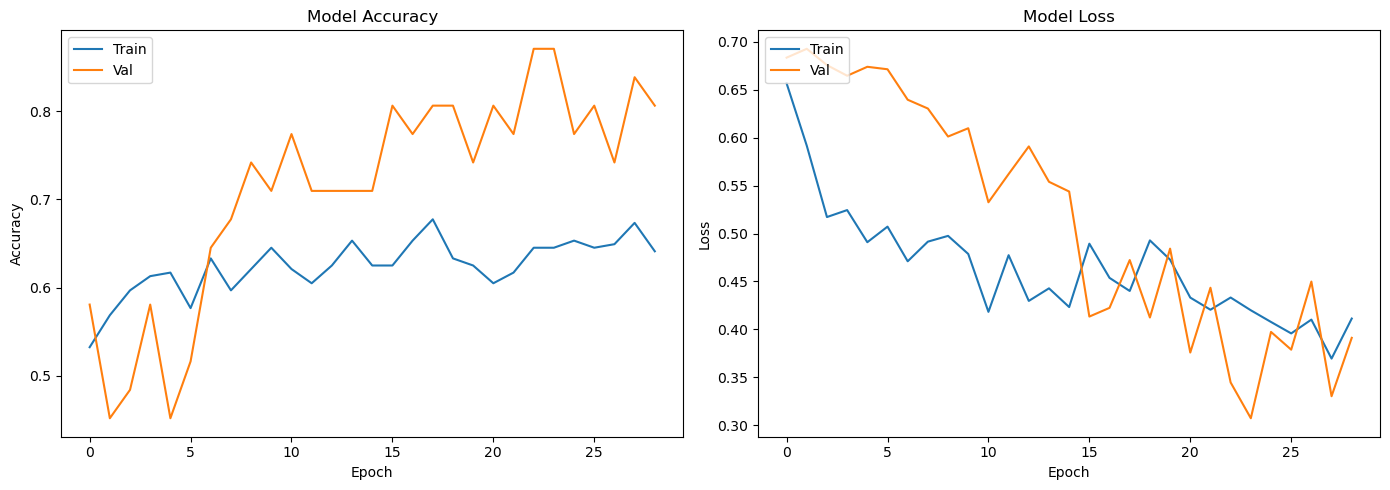

In [21]:
# Create a figure with a row of two subplots
plt.figure(figsize=(14, 5))

# Plot accuracy on the first subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot loss on the second subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
# plt.ylim((0, np.min([5, np.max([history.history['loss'], history.history['val_loss']])])))
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Show the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


In [22]:
loss, accuracy, auc = model.evaluate(test_gen)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test AUC: {round(auc, 4)}%")
print(f"Test loss: {round(loss, 5)}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 711ms/step - accuracy: 0.7805 - auc: 0.8667 - loss: 0.5088
Test accuracy: 78.05%
Test AUC: 0.8667%
Test loss: 0.50879


In [23]:
predictions = model.predict(test_gen)
y_preds = (predictions >= 0.5).astype(int).flatten()
y_true = np.concatenate([y for _, y in test_gen], axis=0) # [int(i > 0) for i in y_test]#

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 621ms/step


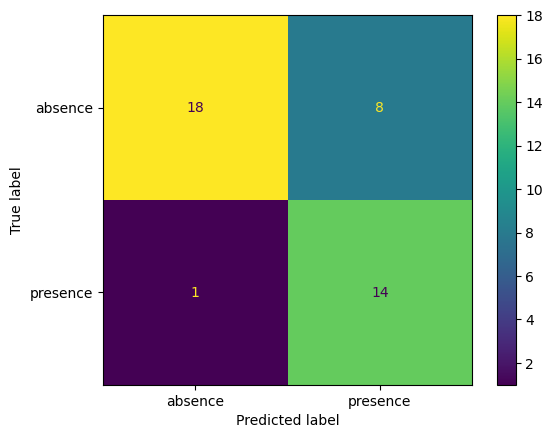

In [24]:
conf_mat = confusion_matrix(["presence" if i==1 else "absence" for i in y_true], ["presence" if i==1 else "absence" for i in y_preds])
disp = ConfusionMatrixDisplay(conf_mat, display_labels=["absence", "presence"])
disp.plot()

In [25]:
print(classification_report(y_true, y_preds, target_names=["absence", "presence"]))

              precision    recall  f1-score   support

     absence       0.95      0.69      0.80        26
    presence       0.64      0.93      0.76        15

    accuracy                           0.78        41
   macro avg       0.79      0.81      0.78        41
weighted avg       0.83      0.78      0.78        41



In [26]:
from sklearn import metrics

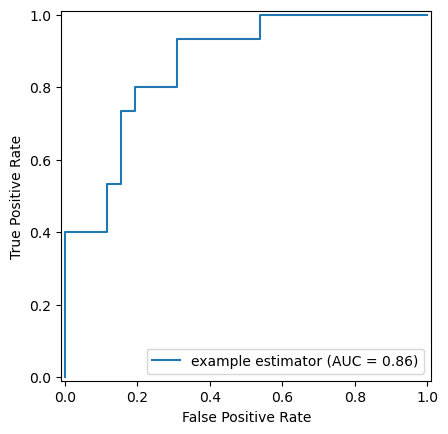

In [27]:
fpr, tpr, thresholds = roc_curve(y_true, predictions.flatten())
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [28]:
model.save('models/pleco_dronems2m5.h5')

# GradCam

In [31]:
# 1. Clone the architecture
copied_model = tf.keras.models.clone_model(model)

# 2. Manually copy the trained weights over!
copied_model.set_weights(model.get_weights())

In [32]:
X_test = np.concatenate([x for x, _ in test_gen], axis=0)
y_test = np.concatenate([y for _, y in test_gen], axis=0) 
print(X_test.shape, y_test.shape)

(41, 40, 40, 5) (41,)


In [33]:
# Remove last layer's softmax
copied_model.layers[-1].activation = None

# Print what the top predicted class is
preds = copied_model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


In [34]:
arg_presence = []

for i in range(len(preds.flatten())):
    if (((preds > 0)*1).flatten()[i] == 1) & ((y_test).astype(int)[i] ==  1):
        arg_presence.append(i)

In [35]:
idx = arg_presence[0]

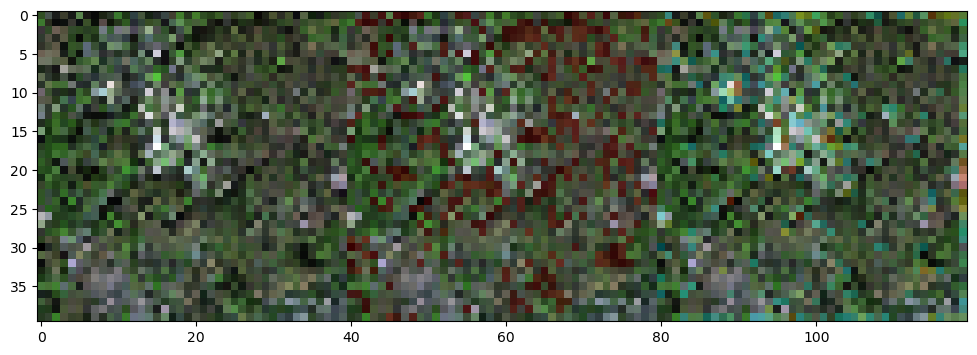

In [36]:
fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(np.hstack([np.round(X_test[idx:idx+1,:,:,:3][0]*255).astype(int),
                     overlay_heatmap(X_test[idx:idx+1,:,:,:3][0], cv2.resize(make_gradcam_heatmap(X_test[idx:idx+1], copied_model, "conv2d"), tuple(X_test.shape[1:3]), interpolation=cv2.INTER_LINEAR), alpha=0.3, threshold=80), 
                      overlay_heatmap(X_test[idx:idx+1,:,:,:3][0], cv2.resize(make_gradcam_heatmap(X_test[idx:idx+1], copied_model, "conv2d_1"), tuple(X_test.shape[1:3]), interpolation=cv2.INTER_LINEAR), alpha=0.3, threshold=80)]))

In [38]:
for i in ['', "_1"]:
    for idx in arg_presence:
        basename = os.path.basename(test_patches[idx:idx+1][0][0]).split('.')[0]
        # Generate class activation heatmap
        heatmap = make_gradcam_heatmap(X_test[idx:idx+1], copied_model, f"conv2d{i}")
        rgb = X_test[idx:idx+1,:,:,:3][0]

        cv2.imwrite(f'gradcams/plecoptera/DroneMS2m5/heatmap_{basename}_conv2d{i}.png', heatmap * 255)
        cv2.imwrite(f'gradcams/plecoptera/DroneMS2m5/rgb_{basename}.png', rgb * 255)